In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

math_df = pd.read_excel("Students_Performance_Maths.xlsx")
port_df = pd.read_excel("Students_Performance_Portuguese.xlsx")
sample_df = pd.read_excel("Prediction_Sample.xlsx")

math_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,Scores
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,5.670000
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,5.333333
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,8.333333
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,14.666667
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,8.666667


In [3]:
math_df.info()
port_df.info()
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385 entries, 0 to 384
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      385 non-null    object 
 1   sex         385 non-null    object 
 2   age         385 non-null    int64  
 3   address     385 non-null    object 
 4   famsize     385 non-null    object 
 5   Pstatus     385 non-null    object 
 6   Medu        385 non-null    int64  
 7   Fedu        385 non-null    int64  
 8   Mjob        385 non-null    object 
 9   Fjob        385 non-null    object 
 10  reason      385 non-null    object 
 11  guardian    385 non-null    object 
 12  traveltime  385 non-null    int64  
 13  studytime   385 non-null    int64  
 14  failures    385 non-null    int64  
 15  schoolsup   385 non-null    object 
 16  famsup      385 non-null    object 
 17  paid        385 non-null    object 
 18  activities  385 non-null    object 
 19  nursery     385 non-null    o

In [9]:
print(math_df.columns)
print(port_df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'Scores'],
      dtype='object')
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', '  Scores'],
      dtype='object')


In [13]:
math_df.columns = math_df.columns.str.strip()
port_df.columns = port_df.columns.str.strip()

In [15]:
math_df.groupby("nursery")["Scores"].mean()
port_df.groupby("nursery")["Scores"].mean()

nursery
no     11.433071
yes    11.710938
Name: Scores, dtype: float64

In [17]:
from scipy.stats import ttest_ind

yes = math_df[math_df["paid"] == "yes"]["Scores"]
no = math_df[math_df["paid"] == "no"]["Scores"]

ttest_ind(yes, no)

TtestResult(statistic=1.9883752197393016, pvalue=0.04748155994326464, df=383.0)

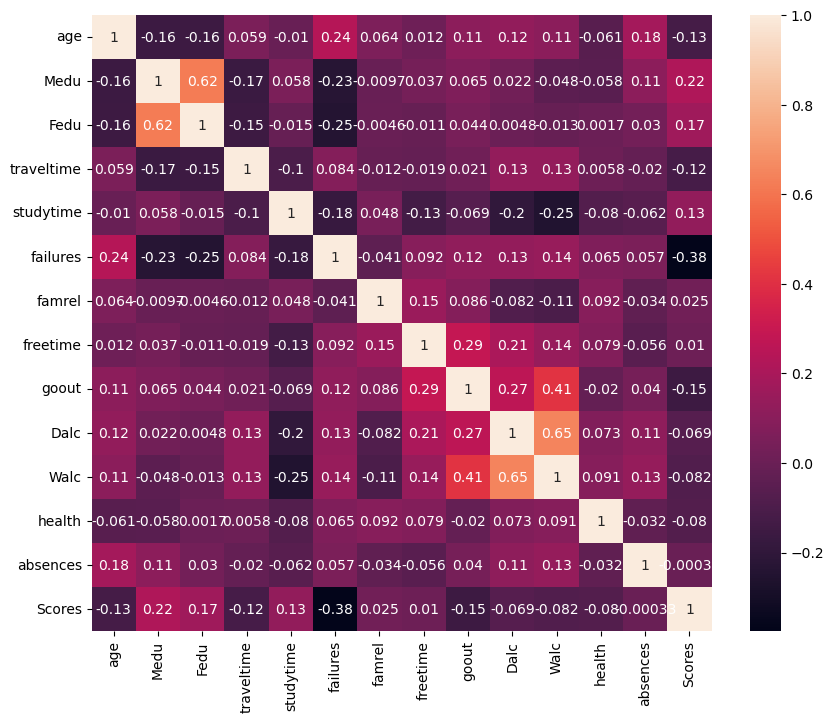

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(math_df.corr(numeric_only=True), annot=True)
plt.show()

In [21]:
df = pd.get_dummies(math_df, drop_first=True)

X = df.drop("Scores", axis=1)
y = df["Scores"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [25]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

RMSE: 3.811507849480868
R2: 0.08241020688641265


In [27]:
sample_df = pd.read_excel("Prediction_Sample.xlsx")

sample_encoded = pd.get_dummies(sample_df)
sample_encoded = sample_encoded.reindex(columns=X.columns, fill_value=0)

predictions = model.predict(sample_encoded)

sample_df["Predicted_Scores"] = predictions

sample_df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,Scores,Predicted_Scores
0,GP,F,15,R,GT3,T,3,4,services,health,...,no,4,3,2,1,1,5,2,??,11.238798
1,GP,F,15,R,GT3,T,2,2,at_home,other,...,no,4,3,1,1,1,2,8,??,10.237429
2,GP,F,16,U,LE3,T,2,2,other,other,...,yes,3,3,3,1,2,3,25,??,8.439896
3,GP,M,15,U,LE3,T,4,4,teacher,other,...,yes,5,4,3,2,4,5,8,??,11.193855
4,GP,M,15,U,GT3,T,4,4,services,teacher,...,no,4,3,3,1,1,5,2,??,14.415935
5,GP,M,15,U,GT3,T,2,2,services,services,...,no,5,4,1,1,1,1,0,??,12.353241
6,GP,F,16,U,LE3,T,2,2,other,at_home,...,no,4,3,3,2,2,5,14,??,9.067693
7,GP,F,15,U,LE3,A,4,3,other,other,...,yes,5,2,2,1,1,5,8,??,9.718208
8,GP,F,16,U,LE3,A,3,3,other,services,...,no,2,3,5,1,4,3,12,??,10.233402
9,GP,M,16,U,GT3,T,4,3,health,services,...,no,4,2,2,1,1,2,4,??,16.167032


In [29]:
sample_df[["Predicted_Scores"]]

,Predicted_Scores
0,11.238798
1,10.237429
2,8.439896
3,11.193855
4,14.415935
5,12.353241
6,9.067693
7,9.718208
8,10.233402
9,16.167032


In [31]:
result = sample_df[["Predicted_Scores"]].copy()
result.index = range(1, 11)  # make it Student 1–10
result

,Predicted_Scores
1,11.238798
2,10.237429
3,8.439896
4,11.193855
5,14.415935
6,12.353241
7,9.067693
8,9.718208
9,10.233402
10,16.167032


In [33]:
avg = port_df["Scores"].mean()

port_df["Proficiency"] = port_df["Scores"].apply(
    lambda x: "Good" if x >= avg else "Not Good"
)

In [35]:
avg = port_df["Scores"].mean()

port_df["Proficiency"] = port_df["Scores"].apply(
    lambda x: "Good" if x >= avg else "Not Good"
)

port_df[["Scores", "Proficiency"]].head()

,Scores,Proficiency
0,7.333333,Not Good
1,10.333333,Not Good
2,12.333333,Good
3,14.000000,Good
4,12.333333,Good


In [37]:
df_c = pd.get_dummies(port_df, drop_first=True)

X = df_c.drop(["Scores", "Proficiency_Not Good"], axis=1)
y = df_c["Proficiency_Not Good"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [41]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7109375
              precision    recall  f1-score   support

       False       0.71      0.75      0.73        67
        True       0.71      0.67      0.69        61

    accuracy                           0.71       128
   macro avg       0.71      0.71      0.71       128
weighted avg       0.71      0.71      0.71       128

[[50 17]
 [20 41]]
